In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [5]:
df = pd.read_csv('loan_data.csv')

print(df.shape)
df.head()

(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
df.info()
print("\nMissing Values:\n")
print(df.isnull().sum())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Missing Values:

Loan_ID               0
Gender               13
Married               3
Dependents           1

In [7]:
# Categorical columns - mode (sabse zyada repeat hone wali value) se fill karo
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical columns - median se fill karo
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

# Verify - ab sab 0 hone chahiye
print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [8]:
# Total Income banao - Applicant aur Coapplicant ki income jodo
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Income skewed hoti hai (kuch log bahut zyada kamate hain), isliye log transform karo
df['Total_Income_log'] = np.log(df['Total_Income'])
df['LoanAmount_log'] = np.log(df['LoanAmount'])

# Dependents column mein '3+' text hai, use number 3 mein convert karo
df['Dependents'] = df['Dependents'].replace('3+', '3')
df['Dependents'] = df['Dependents'].astype(int)

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Total_Income_log,LoanAmount_log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849.0,8.674026,4.852030
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,6091.0,8.714568,4.852030
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000.0,8.006368,4.189655
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,4941.0,8.505323,4.787492
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000.0,8.699515,4.948760


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Ye saare columns text (categorical) hain, inhe number mein convert karenge
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Total_Income_log,LoanAmount_log
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1,5849.0,8.674026,4.852030
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0,6091.0,8.714568,4.852030
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1,3000.0,8.006368,4.189655
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1,4941.0,8.505323,4.787492
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1,6000.0,8.699515,4.948760


In [10]:
# Loan_ID sirf ek identifier hai (jaise roll number), prediction mein iska koi kaam nahi
df = df.drop('Loan_ID', axis=1)

# X = saare features (jinke basis pe prediction karni hai)
# y = target (jo predict karna hai - Loan_Status)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (614, 14)
y shape: (614,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 14)
Testing data: (123, 14)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Teen alag models banate hain
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Har model ko train karo aur accuracy check karo
for name, model in models.items():
    model.fit(X_train, y_train)          # training - model data se seekh raha hai
    preds = model.predict(X_test)         # testing - unseen data pe prediction
    acc = accuracy_score(y_test, preds)   # kitna sahi predict kiya
    print(f"{name} Accuracy: {acc:.4f}")

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.7886
Decision Tree Accuracy: 0.6911
Random Forest Accuracy: 0.7724


In [13]:
from sklearn.metrics import confusion_matrix, classification_report

# Best model - Logistic Regression
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

print("\nClassification Report:")
print(classification_report(y_test, preds))

Confusion Matrix:
[[18 25]
 [ 1 79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ab dobara Logistic Regression train karo scaled data pe
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_scaled, y_train)
preds = best_model.predict(X_test_scaled)

print("Accuracy after scaling:", accuracy_score(y_test, preds))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))
print("\nClassification Report:")
print(classification_report(y_test, preds))

Accuracy after scaling: 0.7804878048780488

Confusion Matrix:
[[18 25]
 [ 2 78]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



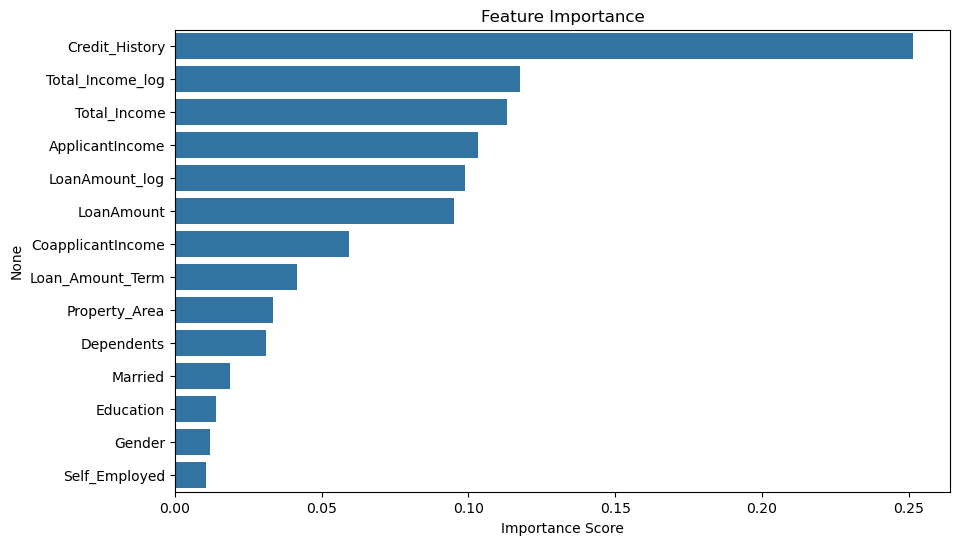

Credit_History       0.251435
Total_Income_log     0.117567
Total_Income         0.113031
ApplicantIncome      0.103417
LoanAmount_log       0.098761
LoanAmount           0.095216
CoapplicantIncome    0.059366
Loan_Amount_Term     0.041554
Property_Area        0.033345
Dependents           0.030967
Married              0.018771
Education            0.013875
Gender               0.012099
Self_Employed        0.010596
dtype: float64


In [15]:
# Random Forest use karenge feature importance nikalne ke liye
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

print(importance)

In [16]:
import joblib

# Best model (scaled Logistic Regression) aur scaler dono save karo
joblib.dump(best_model, "loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")


Model saved successfully!


In [17]:
sample = pd.DataFrame(
    {
        "Gender": [1],  # 1 = Male, 0 = Female
        "Married": [1],  # 1 = Yes, 0 = No
        "Dependents": [0],
        "Education": [0],  # 0 = Graduate, 1 = Not Graduate
        "Self_Employed": [0],  # 0 = No, 1 = Yes
        "ApplicantIncome": [5000],
        "CoapplicantIncome": [0],
        "LoanAmount": [130],
        "Loan_Amount_Term": [360],
        "Credit_History": [1],  # 1 = Good history, 0 = Bad
        "Property_Area": [2],  # 0=Rural, 1=Semiurban, 2=Urban
        "Total_Income": [5000],
        "Total_Income_log": [np.log(5000)],
        "LoanAmount_log": [np.log(130)],
    }
)
sample

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Total_Income,Total_Income_log,LoanAmount_log
0,1,1,0,0,0,5000,0,130,360,1,2,5000,8.517193,4.867534


In [18]:
# Ek sample customer ka data manually banate hain
sample = pd.DataFrame(
    {
        "Gender": [1],  # 1 = Male, 0 = Female
        "Married": [1],  # 1 = Yes, 0 = No
        "Dependents": [0],
        "Education": [0],  # 0 = Graduate, 1 = Not Graduate
        "Self_Employed": [0],  # 0 = No, 1 = Yes
        "ApplicantIncome": [5000],
        "CoapplicantIncome": [0],
        "LoanAmount": [130],
        "Loan_Amount_Term": [360],
        "Credit_History": [1],  # 1 = Good history, 0 = Bad
        "Property_Area": [2],  # 0=Rural, 1=Semiurban, 2=Urban
        "Total_Income": [5000],
        "Total_Income_log": [np.log(5000)],
        "LoanAmount_log": [np.log(130)],
    }
)

# Same order mein columns honi chahiye jaisi X mein thi
sample = sample[X.columns]

# Scale karo (same scaler use karo jo training mein use hua tha)
sample_scaled = scaler.transform(sample)

# Predict karo
prediction = best_model.predict(sample_scaled)
probability = best_model.predict_proba(sample_scaled)

print("Prediction:", "Approved" if prediction[0] == 1 else "Rejected")
print("Probability [Reject, Approve]:", probability[0])

Prediction: Approved
Probability [Reject, Approve]: [0.14481569 0.85518431]
